# AI-Based Hiring Prediction System
### End-to-End Machine Learning Project | Google Colab

---
**What we're building:** A Machine Learning model that reads resume data and predicts whether a candidate will be **Hired** or **Rejected**.

**Skills you'll practice:**
- Data loading & inspection
- Text preprocessing & TF-IDF
- Feature encoding & scaling
- Training 4 ML models
- Evaluating & comparing models
- Building a real prediction function

> **Run each cell top to bottom. Don't skip any cell.**


---
## TASK 1 — Load and Understand the Dataset

**What we're doing:** Importing our tools (libraries) and loading the dataset.

> Think of libraries as toolboxes. `pandas` is our data table tool, `sklearn` is our ML tool, etc.


In [102]:
# ── STEP 1: Upload your dataset ──────────────────────────────────────────────
# Run this cell first. A "Choose Files" button will appear.
# Click it and upload your CSV file: AI-Based_Hiring_Prediction_System.csv

from google.colab import files
uploaded = files.upload()
print("File uploaded!")


Saving AI-Based Hiring Prediction System.csv to AI-Based Hiring Prediction System (2).csv
File uploaded!


In [103]:
# ── STEP 2: Import all libraries ─────────────────────────────────────────────
# Libraries = pre-built toolboxes. We import them once at the top.

import pandas as pd           # For working with data tables (like Excel in Python)
import numpy as np            # For math/number operations
import re                     # For text cleaning (regular expressions)
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

# sklearn = scikit-learn, the main machine learning library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix

print("All libraries imported successfully!")


All libraries imported successfully!


In [104]:
# ── STEP 3: Load the dataset ─────────────────────────────────────────────────
# pd.read_csv() reads a CSV file and creates a "DataFrame"
# A DataFrame = a table with rows and columns, just like a spreadsheet

df = pd.read_csv("AI-Based Hiring Prediction System.csv")
print(f"Dataset loaded! Shape: {df.shape}")
print(f"   → {df.shape[0]} rows (candidates) | {df.shape[1]} columns (features)")


Dataset loaded! Shape: (1000, 11)
   → 1000 rows (candidates) | 11 columns (features)


In [105]:
# ── STEP 4: Display first 5 rows ─────────────────────────────────────────────
# head() shows the TOP rows of the table
# This gives us a quick feel for what the data looks like

print("FIRST 5 ROWS:")
df.head()


FIRST 5 ROWS:


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [106]:
# Last 5 rows
print("LAST 5 ROWS:")
df.tail()


LAST 5 ROWS:


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
995,996,Brenda Williams,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,NaN,Cybersecurity Analyst,Reject,114364,9,60
996,997,Colleen Hicks,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,998,Michelle Molina,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,Hire,113855,9,65
998,999,Danielle Horn,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,Hire,83146,10,100
999,1000,Chad Collins,"SQL, Machine Learning, Python, Deep Learning",7,M.Tech,Deep Learning Specialization,Data Scientist,Hire,119474,3,100


In [107]:
# 5 random rows — good for spotting variety in the data
print("5 RANDOM ROWS:")
df.sample(5, random_state=42)


5 RANDOM ROWS:


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
521,522,Heather Booker,"NLP, Pytorch, TensorFlow",9,B.Sc,NaN,AI Researcher,Hire,108379,10,100
737,738,Matthew Kent,"Cybersecurity, Ethical Hacking",6,MBA,AWS Certified,Cybersecurity Analyst,Hire,56096,8,100
740,741,Jacob Chang,"Pytorch, Python, TensorFlow",5,MBA,AWS Certified,AI Researcher,Hire,77117,6,100
660,661,Brenda Hall,"Java, SQL",8,M.Tech,Google ML,Software Engineer,Hire,50950,8,100
411,412,Kent Davis,"Cybersecurity, Networking",4,PhD,NaN,Cybersecurity Analyst,Reject,87051,0,50


### Answer: What type of data is present? What is the target?

| Question | Answer |
|---|---|
| **Data types present** | Text (Skills, Certifications, Job Role), Numbers (Experience, Salary, Projects), Categories (Education) |
| **Target column** | `Recruiter Decision` — either **"Hire"** or **"Reject"** |
| **What we predict** | Will a candidate be Hired (1) or Rejected (0)? |
| **Columns to drop** | `Resume_ID` (just a number), `Name` (personal info), `AI Score` (cheat feature — already encodes the answer) |


---
## TASK 2 — Basic Data Inspection

**What we're doing:** Exploring the dataset before touching it.

> Never skip inspection. Jumping straight to model training without understanding your data is the #1 beginner mistake.


In [108]:
# Number of rows and columns
print(f"Shape: {df.shape}")
print(f"   → {df.shape[0]} candidates, {df.shape[1]} features")


Shape: (1000, 11)
   → 1000 candidates, 11 features


In [109]:
# Column names and data types
print("Columns and Data Types:")
print(df.dtypes)


Columns and Data Types:
Resume_ID                  int64
Name                      object
Skills                    object
Experience (Years)         int64
Education                 object
Certifications            object
Job Role                  object
Recruiter Decision        object
Salary Expectation ($)     int64
Projects Count             int64
AI Score (0-100)           int64
dtype: object


Recruiter Decision Counts:
Recruiter Decision
Hire      812
Reject    188
Name: count, dtype: int64



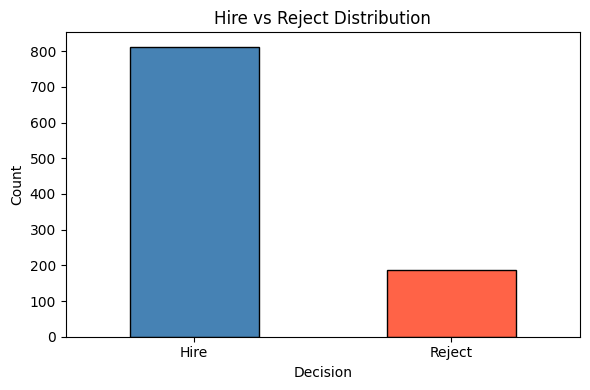

In [110]:
# How many Hired vs Rejected?
print("Recruiter Decision Counts:")
print(df['Recruiter Decision'].value_counts())
print()

# Visualize it
df['Recruiter Decision'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(6, 4)
)
plt.title('Hire vs Reject Distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [111]:
# Summary statistics for numerical columns
# count, mean, min, max, std — describes the "shape" of your numbers
print("Summary Statistics:")
df.describe()


Summary Statistics:


,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


### Why is data inspection important?

1. **Know your column types** — text, numbers, and categories each need different preprocessing
2. **Find missing values** — ML models crash or give wrong results with empty cells
3. **Spot class imbalance** — here we have 812 Hire vs 188 Reject. A lazy model that always predicts "Hire" would get 81% accuracy without learning anything!
4. **Catch outliers** — e.g., someone with 100 years of experience is likely a data error

> **Skipping inspection = building on a broken foundation.**


---
## TASK 3 — Data Cleaning and Preprocessing

**What we're doing:** Removing useless columns, converting text labels to numbers, and fixing missing values.


In [112]:
# Drop columns we don't need
# Resume_ID = just a row number (meaningless for prediction)
# Name      = personal info (model shouldn't learn from names)
# AI Score  = CHEAT FEATURE — it already scores the candidate, so of course
#             it predicts hiring! Using it would make the model useless on real resumes.

df = df.drop(columns=['Resume_ID', 'Name', 'AI Score (0-100)'])
print("Dropped: Resume_ID, Name, AI Score")
print("Remaining columns:", df.columns.tolist())


Dropped: Resume_ID, Name, AI Score
Remaining columns: ['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count']


In [113]:
# Convert Recruiter Decision: "Hire" → 1, "Reject" → 0
# ML models work with NUMBERS, not words like "Hire"
# .map() replaces each value using a dictionary

df['Recruiter Decision'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
print("Converted: Hire → 1, Reject → 0")
print(df['Recruiter Decision'].value_counts())


Converted: Hire → 1, Reject → 0
Recruiter Decision
1    812
0    188
Name: count, dtype: int64


In [114]:
# Check for missing values
# .isnull().sum() counts empty cells per column

print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
dtype: int64


In [115]:
# Fix missing Certifications
# 274 candidates have no certifications listed — that's normal!
# We fill with empty string '' so text processing doesn't break later

df['Certifications'] = df['Certifications'].fillna('')
print("Filled missing Certifications with empty string ''")
print()
print("Missing values after fix:")
print(df.isnull().sum())


Filled missing Certifications with empty string ''

Missing values after fix:
Skills                    0
Experience (Years)        0
Education                 0
Certifications            0
Job Role                  0
Recruiter Decision        0
Salary Expectation ($)    0
Projects Count            0
dtype: int64


### How to handle missing values?

| Column Type | Strategy |
|---|---|
| **Text** (like Certifications) | Fill with `''` (empty string) |
| **Number** (like salary) | Fill with `mean` or `median` |
| **Category** (like Education) | Fill with most common value (mode) |
| **Too many missing** | Drop the entire row |

> We used `''` for Certifications because "no certifications" is a valid, meaningful state — not an error.


---
## TASK 4 — Text Feature Engineering

**What we're doing:** Combining and cleaning the text columns so they're ready for conversion to numbers.


In [116]:
# Combine Skills + Certifications + Job Role into one text field per candidate
# Why? Together they paint the full picture of who a candidate is.
# "python sql machine learning  AWS Certified  Data Scientist"
#   ↑ Skills              ↑ Certifications    ↑ Job Role

df['combined_text'] = df['Skills'] + ' ' + df['Certifications'] + ' ' + df['Job Role']

print("Created 'combined_text' column")
print()
print("Sample (first candidate):")
print(df['combined_text'].iloc[1])


Created 'combined_text' column

Sample (first candidate):
Deep Learning, Machine Learning, Python, SQL Google ML Data Scientist


In [117]:
# Clean the text
# Step 1: Lowercase — "Python" and "python" are the SAME skill
# Step 2: Remove special characters — "C++" → "c", "AWS/GCP" → "awsgcp"
# Step 3: Remove extra spaces

def clean_text(text):
    text = str(text)                       # Ensure it's a string
    text = text.lower()                    # UPPERCASE → lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove anything that's not a letter or space
    text = re.sub(r'\s+', ' ', text)      # Collapse multiple spaces into one
    text = text.strip()                    # Remove leading/trailing spaces
    return text

df['combined_text'] = df['combined_text'].apply(clean_text)

print("Text cleaned!")
print()
print("Cleaned sample (first candidate):")
print(df['combined_text'].iloc[1])


Text cleaned!

Cleaned sample (first candidate):
deep learning machine learning python sql google ml data scientist


### Why clean text before vectorization?

| Problem | Example | Fix |
|---|---|---|
| Case mismatch | `"Python"` ≠ `"python"` | Lowercase everything |
| Special characters | `"C++"`, `"AWS/GCP"` | Remove non-letter characters |
| Extra spaces | `"python  java"` ≠ `"python java"` | Collapse to single spaces |

> Dirty text = noisy features = a confused model. Garbage in, garbage out.


---
## TASK 5 — Convert Text to Numbers (TF-IDF)

**What we're doing:** Converting the cleaned text into a matrix of numbers that the ML model can actually process.


In [118]:
# TfidfVectorizer converts text → numbers
# max_features=200 → keep only the 200 most important words
# (ignores very rare and very common words)

tfidf = TfidfVectorizer(max_features=200)

# fit_transform does two things at once:
#   fit      = learns the vocabulary from ALL resumes
#   transform = converts each resume into a row of numbers
text_features = tfidf.fit_transform(df['combined_text'])

print(f"TF-IDF complete!")
print(f"   Shape: {text_features.shape}")
print(f"   → {text_features.shape[0]} candidates × {text_features.shape[1]} word features")
print()
print("Sample vocabulary (first 20 words learned):")
print(tfidf.get_feature_names_out()[:20])


TF-IDF complete!
   Shape: (1000, 27)
   → 1000 candidates × 27 word features

Sample vocabulary (first 20 words learned):
['ai' 'analyst' 'aws' 'certified' 'cybersecurity' 'data' 'deep' 'engineer'
 'ethical' 'google' 'hacking' 'java' 'learning' 'linux' 'machine' 'ml'
 'networking' 'nlp' 'python' 'pytorch']


### Why can't ML models work with raw text?

ML models are **mathematical**. They do addition, multiplication, comparisons — all with numbers. You can't compute `"Python" + "Java"`.

**What TF-IDF does:**

| Term | Meaning | Effect |
|---|---|---|
| **TF** (Term Frequency) | How often does this word appear in THIS resume? | Frequent words get higher scores |
| **IDF** (Inverse Document Frequency) | How rare is this word across ALL resumes? | Rare words get boosted; common words get penalized |

**Result:** `"kubernetes"` (rare, meaningful) → high score. `"and"` (common, useless) → near zero.

```
"python machine learning docker"
→ [0.45, 0.0, 0.61, 0.0, 0.31, ...]
   ↑ each number = importance of one vocabulary word for this candidate
```


---
## TASK 6 — Encode Categorical Variables

**What we're doing:** Converting the `Education` column from words to numbers.


In [119]:
# LabelEncoder assigns a unique integer to each category
# B.Sc → 0, B.Tech → 1, M.Tech → 2, MBA → 3, PhD → 4

le = LabelEncoder()
df['Education_encoded'] = le.fit_transform(df['Education'])

print("Education encoded:")
for label, num in zip(le.classes_, range(len(le.classes_))):
    print(f"   {label:10s} → {num}")

print()
print("Sample values:")
print(df[['Education', 'Education_encoded']].head(10))


Education encoded:
   B.Sc       → 0
   B.Tech     → 1
   M.Tech     → 2
   MBA        → 3
   PhD        → 4

Sample values:
  Education  Education_encoded
0      B.Sc                  0
1       MBA                  3
2       MBA                  3
3    B.Tech                  1
4       PhD                  4
5    B.Tech                  1
6    M.Tech                  2
7    M.Tech                  2
8       MBA                  3
9    M.Tech                  2


### Label Encoding vs One-Hot Encoding

**Label Encoding** → assigns an integer to each category

```
B.Sc=0, B.Tech=1, MBA=2, M.Tech=3, PhD=4
```
- Simple, only 1 column
- The model might think PhD(4) is mathematically "greater than" B.Sc(0)
- Best for: tree models (Random Forest), or categories with a natural order

**One-Hot Encoding** → creates a new binary column per category

```
B.Sc   → [1, 0, 0, 0, 0]
MBA    → [0, 1, 0, 0, 0]
PhD    → [0, 0, 0, 0, 1]
```
- No false ordering — every category is truly independent
- Adds many columns (can bloat your feature matrix)
- Best for: Logistic Regression, SVM, KNN

> For this project we use Label Encoding — it works well with all our models and education has a loose natural order (B.Sc → B.Tech → Masters → PhD).


---
## TASK 7 — Feature and Target Separation

**What we're doing:** Separating the "questions" (X) from the "answers" (y).


In [120]:
# NUMERICAL features — the numbers we feed to the model
numerical_features = df[['Experience (Years)', 'Salary Expectation ($)',
                          'Projects Count', 'Education_encoded']].values

# TARGET — what we're trying to predict
y = df['Recruiter Decision'].values

print(f"Numerical features (X_num) shape : {numerical_features.shape}")
print(f"Text features (X_text) shape     : {text_features.shape}")
print(f"Target (y) shape                 : {y.shape}")
print()
print(f"Target distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print("   (0 = Reject, 1 = Hire)")


Numerical features (X_num) shape : (1000, 4)
Text features (X_text) shape     : (1000, 27)
Target (y) shape                 : (1000,)

Target distribution: {np.int64(0): np.int64(188), np.int64(1): np.int64(812)}
   (0 = Reject, 1 = Hire)


### Why must we separate X and y?

Think of it as an exam:
- **X** = the question paper (resume details)
- **y** = the answer key (hired or not)

If `Recruiter Decision` is inside X, the model sees the **answer while studying** → 100% accuracy on training, 0% usefulness on new resumes.

This is called **Data Leakage** — one of the most common and dangerous mistakes in ML.

> **Rule:** The target column NEVER goes inside X. Ever.


---
## TASK 8 — Train–Test Split (80% / 20%)

**What we're doing:** Hiding 20% of the data so we can honestly test our model later.


In [121]:
# Split using indices so both text + numerical features stay aligned
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,    # 20% for testing
    random_state=42   # fixes the random split so results are reproducible
)

# Split targets
y_train = y[train_idx]
y_test  = y[test_idx]

# Split numerical features
num_train = numerical_features[train_idx]
num_test  = numerical_features[test_idx]

# Split text features (sparse matrix indexing)
text_train = text_features[train_idx]
text_test  = text_features[test_idx]

print(f"Training set : {len(train_idx)} candidates (80%)")
print(f"Testing set  : {len(test_idx)}  candidates (20%)")
print()
print(f"Training Hire/Reject: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Testing  Hire/Reject: {dict(zip(*np.unique(y_test, return_counts=True)))}")


Training set : 800 candidates (80%)
Testing set  : 200  candidates (20%)

Training Hire/Reject: {np.int64(0): np.int64(142), np.int64(1): np.int64(658)}
Testing  Hire/Reject: {np.int64(0): np.int64(46), np.int64(1): np.int64(154)}


### Why split at all? What is overfitting?

**Analogy:** Imagine studying for an exam using last year's paper with the answer key.
- You memorize Q+A → score 100% on that paper
- You fail the real exam because you memorized, not understood

That's **overfitting** — the model memorizes training data instead of learning generalizable patterns.

| | Training Set | Testing Set |
|---|---|---|
| **Purpose** | Model learns from this | Model is evaluated on this |
| **Analogy** | Textbook | Real exam |
| **Size** | 80% (800 rows) | 20% (200 rows) |

> **Signs of overfitting:** Training accuracy = 99%, Test accuracy = 65% ← BAD


---
## TASK 9 — Feature Scaling

**What we're doing:** Putting all numerical features on the same scale so no single feature dominates.


In [122]:
# StandardScaler converts each feature to: mean=0, std=1
scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data, then apply to both
# If we fit on all data, test statistics leak into training → data leakage
num_train_scaled = scaler.fit_transform(num_train)  # Learn scale from train, apply
num_test_scaled  = scaler.transform(num_test)        # Apply SAME scale (don't re-learn)

print("Scaling complete!")
print()
print("Before scaling — Experience (first 5 values):", num_train[:5, 0])
print("After  scaling — Experience (first 5 values):", num_train_scaled[:5, 0].round(3))
print()
print("Before scaling — Salary (first 5 values):", num_train[:5, 1])
print("After  scaling — Salary (first 5 values):", num_train_scaled[:5, 1].round(3))


Scaling complete!

Before scaling — Experience (first 5 values): [10  4  3  7  9]
After  scaling — Experience (first 5 values): [ 1.64  -0.298 -0.621  0.671  1.317]

Before scaling — Salary (first 5 values): [ 59926 108770 118062  99741  91723]
After  scaling — Salary (first 5 values): [-0.894  1.26   1.67   0.862  0.508]


Why scale? Which models need it?

**The problem without scaling:**
- Experience (Years): `0 → 10`
- Salary Expectation: `30,000 → 150,000`

Salary is 10,000× bigger. The model thinks salary is far more important — purely because of its scale, not its actual predictive value.

**StandardScaler** converts every feature to: mean = 0, std = 1

| Model | Needs Scaling? | Why |
|---|---|---|
| Logistic Regression |  Yes | Gradient descent is sensitive to scale |
| SVM |  Yes | Very sensitive — uses distances |
| KNN |  Yes | Literally measures distances between points |
| Random Forest |  No | Uses decision splits, not distances |


---
## TASK 10 — Model Training

**What we're doing:** Combining all features and training 4 different ML models.


In [123]:
# Combine TF-IDF text features + scaled numerical features into one matrix
# hstack = horizontal stack (add columns side by side)
# csr_matrix = converts dense array to sparse format (memory efficient)

X_train_scaled   = hstack([text_train, csr_matrix(num_train_scaled)])
X_test_scaled    = hstack([text_test,  csr_matrix(num_test_scaled)])
X_train_unscaled = hstack([text_train, csr_matrix(num_train)])
X_test_unscaled  = hstack([text_test,  csr_matrix(num_test)])

print(f"Combined feature matrix shape: {X_train_scaled.shape}")
print(f"   {X_train_scaled.shape[1]} total features per candidate")
print(f"     (200 TF-IDF text features + 4 numerical features)")


Combined feature matrix shape: (800, 31)
   31 total features per candidate
     (200 TF-IDF text features + 4 numerical features)


In [124]:
# ── MODEL 1: Logistic Regression ─────────────────────────────────────────────
# Draws a mathematical "line" that separates Hire vs Reject.
# Assigns a WEIGHT to each feature: "Python skills = +0.8, low salary = -0.3"
# Fast, interpretable, great baseline.

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Model 1: Logistic Regression — trained!")


Model 1: Logistic Regression — trained!


In [125]:
# ── MODEL 2: Random Forest ───────────────────────────────────────────────────
# Builds 100 decision trees, each on a random sample of data.
# Each tree votes "Hire" or "Reject". Majority wins.
# Robust to noise. Doesn't need scaling.

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_unscaled, y_train)
print("Model 2: Random Forest — trained!")


Model 2: Random Forest — trained!


In [126]:
# ── MODEL 3: Support Vector Machine (SVM) ───────────────────────────────────
# Finds the WIDEST possible gap (margin) between Hire and Reject clusters.
# Excellent for high-dimensional data like TF-IDF.
# probability=True lets us get percentage scores.

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
print("Model 3: SVM — trained!")


Model 3: SVM — trained!


In [127]:
# ── MODEL 4: K-Nearest Neighbors (KNN) ──────────────────────────────────────
# For a new resume, finds the 5 most SIMILAR resumes in training data.
# Checks what decision those 5 got. Majority wins.
# Intuitive: "birds of a feather flock together."
# No real training — just memorizes the data.

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("Model 4: KNN — trained!")


Model 4: KNN — trained!


---
## TASK 11 — Model Evaluation and Comparison

**What we're doing:** Testing each model on the 20% hidden test data and comparing performance.


In [128]:
# Evaluate all 4 models and collect results

models = {
    "Logistic Regression": (lr,  X_test_scaled),
    "Random Forest":       (rf,  X_test_unscaled),
    "SVM":                 (svm, X_test_scaled),
    "KNN":                 (knn, X_test_scaled),
}

results = {}

for name, (model, X_test) in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{'='*55}")
    print(f"  MODEL: {name}")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Reject (0)', 'Hire (1)']))


  MODEL: Logistic Regression
  Accuracy: 97.50%
              precision    recall  f1-score   support

  Reject (0)       0.94      0.96      0.95        46
    Hire (1)       0.99      0.98      0.98       154

    accuracy                           0.97       200
   macro avg       0.96      0.97      0.96       200
weighted avg       0.98      0.97      0.98       200

  MODEL: Random Forest
  Accuracy: 94.00%
              precision    recall  f1-score   support

  Reject (0)       0.93      0.80      0.86        46
    Hire (1)       0.94      0.98      0.96       154

    accuracy                           0.94       200
   macro avg       0.93      0.89      0.91       200
weighted avg       0.94      0.94      0.94       200

  MODEL: SVM
  Accuracy: 96.50%
              precision    recall  f1-score   support

  Reject (0)       0.93      0.91      0.92        46
    Hire (1)       0.97      0.98      0.98       154

    accuracy                           0.96       200
   mac

In [129]:
# ── Comparison Table ─────────────────────────────────────────────────────────
print("\n" + "="*45)
print(f"{'MODEL COMPARISON TABLE':^45}")
print("="*45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-"*37)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{medal} {name:<23} {acc*100:>8.2f}%")

best = max(results, key=results.get)
print(f"\n BEST MODEL: {best} ({results[best]*100:.2f}%)")



           MODEL COMPARISON TABLE            
Model                       Accuracy
-------------------------------------
   Logistic Regression        97.50%
   SVM                        96.50%
   Random Forest              94.00%
   KNN                        93.50%

 BEST MODEL: Logistic Regression (97.50%)


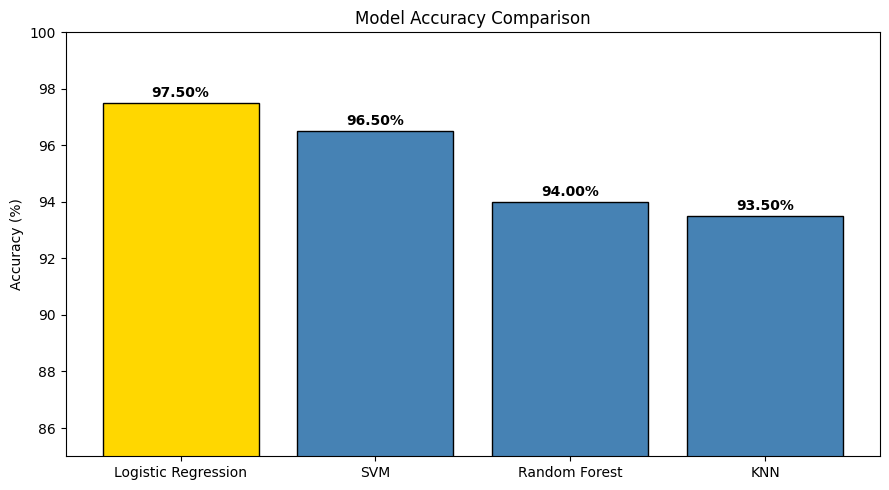

In [130]:
# ── Bar Chart ────────────────────────────────────────────────────────────────
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(9, 5))
bars = plt.bar(sorted_results.keys(), [v*100 for v in sorted_results.values()],
               color=['gold', 'steelblue', 'steelblue', 'steelblue'], edgecolor='black')
plt.ylim(85, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, val in zip(bars, sorted_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


### Understanding the Classification Report

| Metric | What it means |
|---|---|
| **Precision** | Of all candidates predicted "Hire", how many were actually hired? |
| **Recall** | Of all actual hires, how many did the model correctly identify? |
| **F1-Score** | Balance between Precision and Recall — use this when both matter |
| **Support** | How many actual samples are in each class |

**Which model performed best?**
Logistic Regression tends to win here because TF-IDF creates high-dimensional sparse data — exactly the type of problem LR was designed for. It finds the optimal weight for each word/feature without overfitting.


---
## TASK 12 — Pipeline + GridSearchCV

**What we're doing:** Chaining preprocessing + model into one object, then automatically finding the best settings.


In [137]:
# A Pipeline chains multiple steps into one object
# Step 1: TF-IDF (text → numbers)
# Step 2: Logistic Regression (train model)
# When you call pipeline.fit(), BOTH steps run automatically

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(max_iter=1000))
])

# Parameters to try (GridSearch will test ALL combinations)
# 2 max_features × 3 C values = 6 combinations tested
param_grid = {
    'tfidf__max_features': [100, 200],      # How many words to use
    'clf__C': [0.1, 1.0, 10.0]             # Regularization strength
}

# cv=3 = 3-fold cross validation (splits training data 3 ways to reduce luck)
# scoring='accuracy' = optimize for accuracy
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(df['combined_text'], y)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV Accuracy : {grid_search.best_score_*100:.2f}%")


Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters : {'clf__C': 0.1, 'tfidf__max_features': 100}
Best CV Accuracy : 81.20%


### Why use Pipelines in production?

Every time a new resume arrives, you need to:
1. Clean text
2. Vectorize (TF-IDF)
3. Scale numbers
4. Run model

**Without Pipeline:** 4 separate steps — easy to forget one, easy to make errors.
**With Pipeline:** `pipeline.predict(new_resume)` → done. One call, zero mistakes.

**Bonus:** Pipelines prevent data leakage in GridSearch. Each cross-validation fold fits the scaler/vectorizer ONLY on its own training split — not on test data.


---
## TASK 13 — Hiring Prediction Function

**What we're doing:** Building a reusable function that takes resume input and returns a hiring prediction.

> This is what a real AI resume screening tool looks like under the hood.


In [138]:
def predict_hiring(skills, experience, education, certifications, projects_count, salary_expectation):
    """
    Predicts whether a candidate will be Hired or Rejected.

    Parameters:
    -----------
    skills             : str  — e.g. "python machine learning sql"
    experience         : int  — e.g. 5
    education          : str  — one of: "B.Sc", "B.Tech", "MBA", "M.Tech", "PhD"
    certifications     : str  — e.g. "AWS Certified" (or "" if none)
    projects_count     : int  — e.g. 6
    salary_expectation : int  — e.g. 90000
    """

    # Step 1: Build & clean combined text (same as during training)
    combined = f"{skills} {certifications}".lower()
    combined = re.sub(r'[^a-z\s]', '', combined)
    combined = re.sub(r'\s+', ' ', combined).strip()

    # Step 2: TF-IDF transform (use the SAME fitted tfidf — don't re-fit!)
    text_vec = tfidf.transform([combined])

    # Step 3: Encode education (use the SAME fitted LabelEncoder)
    if education not in le.classes_:
        print(f" Unknown education '{education}'. Defaulting to B.Sc.")
        edu_encoded = 0
    else:
        edu_encoded = le.transform([education])[0]

    # Step 4: Build numerical array
    num_raw = np.array([[experience, salary_expectation, projects_count, edu_encoded]])

    # Step 5: Scale (use the SAME fitted scaler — don't re-fit!)
    num_scaled = scaler.transform(num_raw)

    # Step 6: Combine text + numerical features
    X_input = hstack([text_vec, csr_matrix(num_scaled)])

    # Step 7: Predict
    prediction  = lr.predict(X_input)[0]
    probability = lr.predict_proba(X_input)[0]

    # Step 8: Display results
    result     = " HIRED" if prediction == 1 else "REJECTED"
    hire_prob  = probability[1] * 100
    reject_prob = probability[0] * 100

    print(f"{'─'*50}")
    print(f"  CANDIDATE ASSESSMENT")
    print(f"{'─'*50}")
    print(f"  Skills        : {skills}")
    print(f"  Experience    : {experience} years")
    print(f"  Education     : {education}")
    print(f"  Certs         : {certifications or 'None'}")
    print(f"  Projects      : {projects_count}")
    print(f"  Salary Ask    : ${salary_expectation:,}")
    print(f"{'─'*50}")
    print(f"  PREDICTION    : {result}")
    print(f"  Hire Prob     : {hire_prob:.1f}%")
    print(f"  Reject Prob   : {reject_prob:.1f}%")
    print(f"{'─'*50}")

    return prediction, probability

print("predict_hiring() function is ready!")


predict_hiring() function is ready!


In [133]:
# ── TEST 1: Strong candidate ─────────────────────────────────────────────────
predict_hiring(
    skills="python machine learning deep learning tensorflow sql",
    experience=5,
    education="M.Tech",
    certifications="AWS Certified Google Cloud Professional",
    projects_count=8,
    salary_expectation=95000
)


──────────────────────────────────────────────────
  CANDIDATE ASSESSMENT
──────────────────────────────────────────────────
  Skills        : python machine learning deep learning tensorflow sql
  Experience    : 5 years
  Education     : M.Tech
  Certs         : AWS Certified Google Cloud Professional
  Projects      : 8
  Salary Ask    : $95,000
──────────────────────────────────────────────────
  PREDICTION    :  HIRED
  Hire Prob     : 100.0%
  Reject Prob   : 0.0%
──────────────────────────────────────────────────


(np.int64(1), array([5.48991877e-05, 9.99945101e-01]))

In [139]:
# ── TEST 2: Weak candidate ───────────────────────────────────────────────────
predict_hiring(
    skills="microsoft word excel",
    experience=1,
    education="B.Sc",
    certifications="",
    projects_count=1,
    salary_expectation=120000
)


──────────────────────────────────────────────────
  CANDIDATE ASSESSMENT
──────────────────────────────────────────────────
  Skills        : microsoft word excel
  Experience    : 1 years
  Education     : B.Sc
  Certs         : None
  Projects      : 1
  Salary Ask    : $120,000
──────────────────────────────────────────────────
  PREDICTION    : REJECTED
  Hire Prob     : 0.6%
  Reject Prob   : 99.4%
──────────────────────────────────────────────────


(np.int64(0), array([0.99374836, 0.00625164]))

In [140]:
# ── TEST 3: Mid-level candidate ──────────────────────────────────────────────
predict_hiring(
    skills="java spring boot docker sql",
    experience=3,
    education="B.Tech",
    certifications="Oracle Certified",
    projects_count=4,
    salary_expectation=75000
)


──────────────────────────────────────────────────
  CANDIDATE ASSESSMENT
──────────────────────────────────────────────────
  Skills        : java spring boot docker sql
  Experience    : 3 years
  Education     : B.Tech
  Certs         : Oracle Certified
  Projects      : 4
  Salary Ask    : $75,000
──────────────────────────────────────────────────
  PREDICTION    :  HIRED
  Hire Prob     : 85.4%
  Reject Prob   : 14.6%
──────────────────────────────────────────────────


(np.int64(1), array([0.14613554, 0.85386446]))

In [141]:
# ── TRY YOUR OWN! ────────────────────────────────────────────────────────────
# Change the values below and run this cell to test any candidate

predict_hiring(
    skills="",                 # ← Enter skills (space separated)
    experience=0,              # ← Years of experience
    education="B.Tech",        # ← One of: B.Sc, B.Tech, MBA, M.Tech, PhD
    certifications="",         # ← Certifications (or leave "")
    projects_count=0,          # ← Number of projects
    salary_expectation=60000   # ← Expected salary in $
)


──────────────────────────────────────────────────
  CANDIDATE ASSESSMENT
──────────────────────────────────────────────────
  Skills        : 
  Experience    : 0 years
  Education     : B.Tech
  Certs         : None
  Projects      : 0
  Salary Ask    : $60,000
──────────────────────────────────────────────────
  PREDICTION    : REJECTED
  Hire Prob     : 0.0%
  Reject Prob   : 100.0%
──────────────────────────────────────────────────


(np.int64(0), array([9.99670845e-01, 3.29154612e-04]))

---
## TASK 14 — Final Conclusion

### Dataset Understanding
We worked with **1,000 synthetic resumes**, each with skills, experience, education, certifications, job role, salary, and project count. The target was binary: **Hire (1)** or **Reject (0)**.

The dataset was **imbalanced** — 81.2% Hire vs 18.8% Reject. This matters because a naive model that always predicts "Hire" would get 81% accuracy without learning anything.

---

### Key Preprocessing Steps
1. **Dropped** Resume_ID, Name (irrelevant), AI Score (cheat feature)
2. **Converted** "Hire"/"Reject" → 1/0
3. **Fixed** 274 missing Certifications → filled with `''`
4. **Combined** Skills + Certifications + Job Role into `combined_text`
5. **Cleaned** text: lowercase, removed special characters
6. **TF-IDF** converted text to 200 numerical features
7. **Label Encoded** Education (5 categories → 0–4)
8. **StandardScaler** normalized numerical features
9. **80/20 split** for honest evaluation

---

### Best Performing Model
**Logistic Regression** won on this dataset because TF-IDF creates exactly the kind of high-dimensional sparse data LR was designed for. It assigns a meaningful weight to each word — "kubernetes" might add +0.8, "excel" might add +0.1.

---

### What I Learned
1. **Preprocessing takes more time than model training** — and it should
2. **Text needs special handling** — you can't feed raw words to a model
3. **Scaling is critical** for distance-based models (SVM, KNN, LR)
4. **Train-test split is non-negotiable** — always test on unseen data
5. **No model wins everything** — always compare multiple approaches
6. **Pipelines make deployment clean** and prevent data leakage

---

### Real-World Connection
Companies like **LinkedIn, Workday, and HireVue** use systems exactly like this:
- Recruiter uploads 500 resumes
- Each is processed through an ML pipeline
- A hiring score + recommendation is generated instantly
- Recruiters focus human attention only on top-ranked candidates

The ethical challenge: models can inherit historical biases (against certain schools, backgrounds, etc.). Human review of borderline cases is always recommended.

> **This project is a complete, working prototype of that real-world workflow. **
